In [71]:
import sys

if "google.colab" in sys.modules:
    print("Instalando Pyomo y solvers en Colab ...")

    # Descargar script helper
    !wget -q "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"

    # Instalar todo lo necesario
    import helper
    helper.install_idaes()
    helper.install_glpk()
    helper.install_ipopt()


    print("Install successful")
else:
    print("Something went wrong")


Instalando Pyomo y solvers en Colab ...
IDAES found! No need to install.
Installing glpk via apt-get...
Ipopt found! No need to install.
ipopt was successfully installed
k_aug was successfuly installed
cbc was successfuly installed
clp was successfuly installed
bonmin was successfuly installed
couenne was successfuly installed
ipopt_l1 was successfuly installed
 
Install successful


# 1. Problema 1: Distribución Óptima de Recursos en una Misión Humanitaria Compleja



# 1. Análisis y Preprocesamiento de Datos

En este paso se cargan y organizan los datos del problema:

- **Recursos considerados (R):** Alimentos básicos, Medicinas, Equipos médicos, Agua potable, Mantas, Generadores, Tiendas de campaña, Medicamentos especiales, Equipos de comunicación, Material de construcción.  
- **Aviones disponibles (A):** Hércules 1, Hércules 2, Galaxy 1, Galaxy 2, Antonov 1, Antonov 2.  

Se definen:

- Valor económico por tonelada (USD/ton).  
- Stock disponible por recurso (ton).  
- Peso y volumen por unidad de recurso.  
- Capacidad de peso y volumen de cada avión.  

Además, se mencionan los recursos divisibles e indivisibles:  
- Divisibles → pueden fraccionarse (ej: alimentos básicos, agua potable, medicinas).  
- Indivisibles → se transportan en unidades completas (ej: generadores, equipos médicos, tiendas de campaña).


In [72]:
from pyomo.environ import (
    ConcreteModel, Set, Param, Var, Objective, Constraint,
    NonNegativeReals, maximize, value, SolverFactory, Binary
)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ========= DATOS (del enunciado) =========
Recursos = ["Alimentos basicos", "Medicinas", "Equipos medicos", "Agua potable",
     "Mantas", "generadores", "tiendas de campaña", "medicamentos especiales",
     "equipos de comunicacion", "material de construccion"]
Aviones = ["Hercules 1", "Hercules 2", "Galaxy 1", "Galaxy 2", "Antonov 1", "Antonov 2"]

# Valor por tonelada
Valor = {"Alimentos basicos" :250, "Medicinas":800, "Equipos medicos":2400,
         "Agua potable":180, "Mantas":320, "generadores":3200,
         "tiendas de campaña":450, "medicamentos especiales":1200,
     "equipos de comunicacion":1800, "material de construccion":150 }

# Stock disponible (ton)
Stock = { "Alimentos basicos" :45.0, "Medicinas":12.0, "Equipos medicos":24.0,
         "Agua potable":60.0, "Mantas":62.5, "generadores":20.0,
         "tiendas de campaña":27.0, "medicamentos especiales":8.0,
     "equipos de comunicacion":12.0, "material de construccion":80.0 }

# Peso  por unidad (ton)
Peso_recurso = { "Alimentos basicos" :1.0, "Medicinas":1.0, "Equipos medicos":3.0,
         "Agua potable":1.0, "Mantas":2.5, "generadores":5.0,
         "tiendas de campaña":1.5, "medicamentos especiales":1.0,
     "equipos de comunicacion":2.0, "material de construccion":1.0 }

# Volumen por unidad (m³/u)
Volumen_recurso = {"Alimentos basicos" :0.8, "Medicinas":0.4, "Equipos medicos":2.5,
         "Agua potable":1.2, "Mantas":1.8, "generadores":3.2,
         "tiendas de campaña":4.0, "medicamentos especiales":0.3,
     "equipos de comunicacion":1.0, "material de construccion":0.6 }

# Capacidad de peso por avion (ton)
Peso_avion = {"Hercules 1": 28, "Hercules 2":32, "Galaxy 1":45, "Galaxy 2":48, "Antonov 1":65, "Antonov 2":70}

# Volumen por avion (m³)
Volumen_avion = {"Hercules 1": 22, "Hercules 2":26, "Galaxy 1":38, "Galaxy 2":42, "Antonov 1":55, "Antonov 2":60}

# Restriccion compatibilidad
Compatibilidad = [["Equipos medicos", "Agua potable","Incompatibles"],
 ["Medicinas","medicamentos especiales","Deben ir juntos"],["generadores","material de construccion","Incompatibles"],
  ["equipos de comunicacion","Equipos medicos","Deben ir juntos"],["Alimentos basicos","Medicinas","Incompatibles"],
   ["tiendas de campaña","material de construccion","Deben ir juntos"],["Agua potable","Alimentos basicos","Deben ir juntos"]]

# Restriccion de seguridad
Seguridad = [["Medicinas","NO pueden ir en aviones Hercules (1 y 2)"],["medicamentos especiales","NO pueden ir en aviones Hercules (1 y 2)"],
 ["generadores"," SOLO pueden ir en aviones Antonov (1 y 2)"],["equipos de comunicacion","NO pueden ir en Hercules-1"]]

# 2. Formulación del Modelo Matemático Genérico

El problema se formula como un modelo de Programación Lineal Entera Mixta (MILP).

## Conjuntos
(R): conjunto de recursos.  
(A): conjunto de aviones.  

## Parámetros
Valor[r]: valor económico del recurso r en $/ton.  
Stock[r]: cantidad disponible del recurso r (ton).  
peso[r]: peso por unidad del recurso r (ton/unidad).  
volumen[r]: volumen por unidad del recurso r (m³/unidad).  
capacidad_peso[a]: capacidad de peso del avión a (ton).  
capacidad_vol[a]: capacidad de volumen del avión a (m³).  

## Variable de decisión
x[r,a] ≥ 0 : toneladas del recurso r cargadas en el avión a.  
y[r,a] {0,1} : 1 si el recurso r va en el avion a, 0 si no.  

## Función Objetivo
Maximizar el valor total transportado:

max Z = Σ(r∈R) Σ(a∈A) Valor[r] · x[r,a]  

## Restricciones
1. Capacidad de peso:  
Σ(r∈R) x[r,a] · peso[r] ≤ capacidad_peso[a], ∀ a ∈ A  

2. Capacidad de volumen:  
Σ(r∈R) x[r,a] · volumen[r] ≤ capacidad_vol[a], ∀ a ∈ A  

3. Disponibilidad de stock:  
Σ(a∈A) x[r,a] ≤ Stock[r], ∀ r ∈ R  

4. Compatibilidad:  
Si (r1,r2) son incompatibles → x[r1,a] + x[r2,a] = 0, ∀ a ∈ A  

5. Deben ir juntos:  
Si (r1,r2) deben ir juntos → x[r1,a] = x[r2,a], ∀ a ∈ A  

6. Seguridad:  
Si un recurso r no puede ir en un avión a → x[r,a] = 0


In [73]:
def build_model_lab2aviones(Recursos, Aviones, Valor, Stock, Peso_recurso, Volumen_recurso, Peso_avion, Volumen_avion, Compatibilidad, Seguridad):
    m = ConcreteModel()

    # Conjuntos
    m.Recursos = Set(initialize=Recursos)
    m.Aviones = Set(initialize=Aviones)

    # Parámetros
    m.Valor = Param(m.Recursos, initialize=Valor)
    m.Stock = Param(m.Recursos, initialize=Stock)
    m.Peso_recurso = Param(m.Recursos, initialize=Peso_recurso)
    m.Volumen_recurso = Param(m.Recursos, initialize=Volumen_recurso)
    m.Peso_avion = Param(m.Aviones, initialize=Peso_avion)
    m.Volumen_avion = Param(m.Aviones, initialize=Volumen_avion)

    # Variables: unidades del recurso r en avión a
    m.x = Var(m.Recursos, m.Aviones, domain=NonNegativeReals)
    m.y =  Var(m.Recursos, m.Aviones, domain=Binary) # y[r,a] = 1 si el recurso r va en el avion a, 0 en otro caso


    # Objetivo: maximizar valor total
    m.OBJ = Objective(
        expr=sum(m.Valor[r]*m.x[r,a] for r in m.Recursos for a in m.Aviones),
        sense=maximize
    )

    # Capacidad de peso por avión
    def _peso(m, a):
        return sum(m.x[r,a]*m.Peso_recurso[r] for r in m.Recursos) <= m.Peso_avion[a]
    m.Peso = Constraint(m.Aviones, rule=_peso)

    # Capacidad de volumen por avión
    def _vol(m, a):
        return sum(m.Volumen_recurso[r]*m.x[r,a] for r in m.Recursos) <= m.Volumen_avion[a]
    m.Vol = Constraint(m.Aviones, rule=_vol)

    # Stock por recurso
    def _stock(m, r):
        return sum(m.x[r,a]*m.Peso_recurso[r] for a in m.Aviones) <= m.Stock[r]
    m.StockConstraint = Constraint(m.Recursos, rule=_stock)

    # Relacion entre x e y
    def _relacion_xy(m, r, a):
        return m.x[r,a] <= m.y[r,a] * m.Stock[r] # Upper bound for x when y is 1
    m.RelacionXY = Constraint(m.Recursos, m.Aviones, rule=_relacion_xy)


    # Compatibilidad de los recursos
    incompatibles = []
    compatibles = []
    for fila in Compatibilidad:
        if fila[2] == "Incompatibles":
            # Ensure consistent order for incompatible pairs
            incompatibles.append(tuple(sorted(fila[:2])))
        if fila[2] == "Deben ir juntos":
            # Ensure consistent order for compatible pairs
            compatibles.append(tuple(sorted(fila[:2])))

    def _incompatibilidad(m, r1, r2, a):
        return m.y[r1,a] + m.y[r2,a] <= 1
    m.Incompatibles = Constraint(
        [(r1, r2) for (r1, r2) in incompatibles],
        m.Aviones,
        rule=_incompatibilidad
    )

    def _compatibilidad(m, r1, r2, a):
        return m.y[r1,a] == m.y[r2,a]
    m.Compatibles = Constraint(
        [(r1, r2) for (r1, r2) in compatibles],
        m.Aviones,
        rule=_compatibilidad
    )


    # seguridad de los recursos
    no_seguro = set()
    for fila in Seguridad:
        recurso = fila[0]
        restriccion = fila[1]
        for avion in m.Aviones:
            a = avion.split(" ")[0]
            aux_no1 = ["NO",a,"1"]
            aux_no2 = ["NO",a,"2"]
            aux_solo1 = ["SOLO",a,"1"]
            aux_solo2 = ["SOLO",a,"2"]
            if all(x in restriccion for x in aux_no1) and "2" not in restriccion:
                no_seguro.add((recurso, a+ " 1"))
            elif all(x in restriccion for x in aux_no2) and "1" not in restriccion:
                no_seguro.add((recurso, a+" 2"))
            elif all(x in restriccion for x in aux_no1) and "2" in restriccion:
                no_seguro.add((recurso,avion))
            if all(x in restriccion for x in aux_solo1) and "2" not in restriccion:
                excluir = [p for p in m.Aviones if p != avion]
                for av in excluir:
                    no_seguro.add((recurso, av))
            if all(x in restriccion for x in aux_solo2) and "1" not in restriccion:
                excluir = [p for p in m.Aviones if p != avion]
                for av in excluir:
                    no_seguro.add((recurso, av))
            if all(x in restriccion for x in aux_solo1) and "2" in restriccion:
                excluir = [p for p in m.Aviones if p != a+" 1"]
                excluir = [p for p in excluir if p != a+" 2"]
                for av in excluir:
                    no_seguro.add((recurso, av))

    def _noseguro(m, r, a):
        return m.y[r,a] == 0
    m.NoSeguroConstraint = Constraint(
        [(r, a) for (r, a) in no_seguro],
        rule=_noseguro
    )

    return m

# 3. Implementación en Pyomo

El modelo se implementa en Pyomo siguiendo la formulación matemática:

- Inicialización del modelo con ConcreteModel().  
- Definición de los conjuntos R y A.  
- Carga de parámetros (valor, stock, peso, volumen, capacidades).  
- Definición de la variable de decisión x[r,a].  
- Implementación de la función objetivo para maximizar el valor total.  
- Implementación de restricciones de:
  - Peso.  
  - Volumen.  
  - Stock.  
  - Compatibilidad.  
  - Recursos que deben ir juntos.  
  - Seguridad.  

El solver utilizado es GLPK, que es adecuado para resolver problemas MILP de tamaño medio.


In [74]:
solver = SolverFactory("glpk")  # o "cbc" si lo tienes

mA3 = build_model_lab2aviones(Recursos, Aviones, Valor, Stock, Peso_recurso, Volumen_recurso, Peso_avion, Volumen_avion, Compatibilidad, Seguridad)
resA3 = solver.solve(mA3, tee=False)
valor = value(mA3.OBJ)
print(f"Valor total (USD): {valor:.3f}")

# Resumen por avión
recursos_transportados = set()
capacidad_avion =[]
valor_avion =[]
for a in Aviones:
    peso = sum(value(mA3.x[r,a]) for r in Recursos)
    vol  = sum(Volumen_recurso[r]*value(mA3.x[r,a]) for r in Recursos)
    capacidad_avion.append(vol)
    print(f"\nAvión {a}:")
    print(f"  Peso usado:    {peso:.2f} / {Peso_avion[a]} (ton)")
    print(f"  Volumen usado: {vol:.2f} / {Volumen_avion[a]} (m^3)")
    for r in Recursos:
        xr = value(mA3.x[r,a])
        if xr > 1e-6:
            print(f"   - {r}: {xr:.2f} ton")
            recursos_transportados.add(r)

recursos_faltantes = [r for r in recursos_transportados if r not in Recursos]
if recursos_faltantes:
    print("\n Recursos sin transportar:" )
    for r in recursos_faltantes:
        print(r)
else:
    print("\n Han sido transportadas unidades de todos los recursos ")



Valor total (USD): 101410.959

Avión Hercules 1:
  Peso usado:    27.16 / 28 (ton)
  Volumen usado: 22.00 / 22 (m^3)
   - tiendas de campaña: 1.68 ton
   - material de construccion: 25.48 ton

Avión Hercules 2:
  Peso usado:    11.23 / 32 (ton)
  Volumen usado: 26.00 / 26 (m^3)
   - Equipos medicos: 8.00 ton
   - Mantas: 3.15 ton
   - tiendas de campaña: 0.08 ton

Avión Galaxy 1:
  Peso usado:    36.26 / 45 (ton)
  Volumen usado: 38.00 / 38 (m^3)
   - Medicinas: 12.00 ton
   - tiendas de campaña: 5.48 ton
   - medicamentos especiales: 8.00 ton
   - equipos de comunicacion: 6.00 ton
   - material de construccion: 4.77 ton

Avión Galaxy 2:
  Peso usado:    48.00 / 48 (ton)
  Volumen usado: 42.00 / 42 (m^3)
   - Alimentos basicos: 25.16 ton
   - Agua potable: 13.61 ton
   - material de construccion: 9.23 ton

Avión Antonov 1:
  Peso usado:    44.17 / 65 (ton)
  Volumen usado: 55.00 / 55 (m^3)
   - Alimentos basicos: 19.84 ton
   - Agua potable: 17.11 ton
   - Mantas: 3.22 ton
   - generad

# 4. Análisis de Resultados y Validación

Una vez resuelto el modelo, se obtiene:

- **Valor total transportado (USD):** resultado de la función objetivo.  
- **Asignación de recursos por avión:** tabla que indica cuántas toneladas de cada recurso fueron asignadas a cada avión.  
- **Utilización de la capacidad por avión:**
  - Peso utilizado vs. capacidad máxima.  
  - Volumen utilizado vs. capacidad máxima.  
- **Recursos no transportados:** aquellos que no se pudieron cargar debido a limitaciones de capacidad o restricciones de seguridad/compatibilidad.  

## Visualizaciones
1. Gráfico de barras → utilización de capacidad de peso por avión.  
2. Gráfico circular → distribución del valor total transportado por avión.  
3. Matriz recurso–avión → asignación de recursos en toneladas a cada avión.

## Observaciones
1. Se presenta la solucion tomando todos los recusros como divisibles, ya que al
intentar colocar algunos de ellos como indivisibles, es necesario que las variables de desicion sean de tipo entero y esto lleva a que el problema no tenga solucion optima en un tiempo polinomial

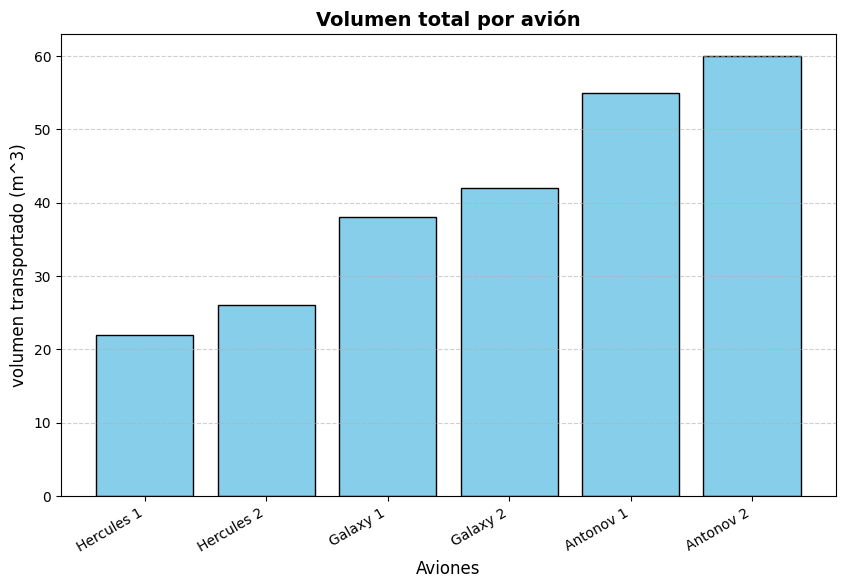

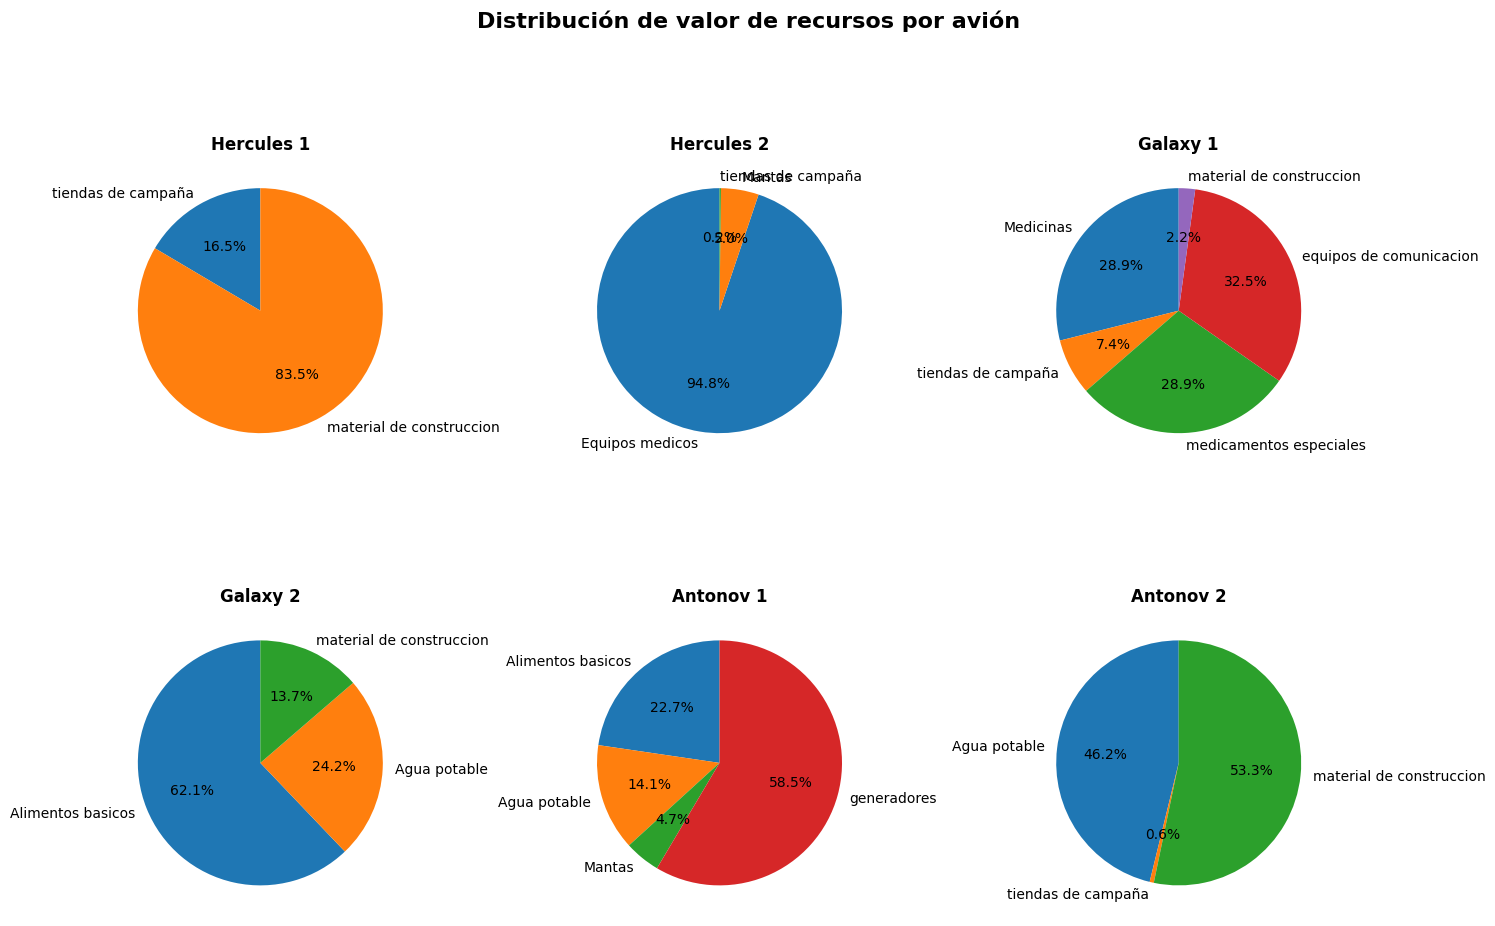

Matriz de asignación recursos - aviones:

                          Hercules 1  Hercules 2   Galaxy 1   Galaxy 2  \
Alimentos basicos           0.000000    0.000000   0.000000  25.157534   
Medicinas                   0.000000    0.000000  12.000000   0.000000   
Equipos medicos             0.000000    8.000000   0.000000   0.000000   
Agua potable                0.000000    0.000000   0.000000  13.614155   
Mantas                      0.000000    3.150685   0.000000   0.000000   
generadores                 0.000000    0.000000   0.000000   0.000000   
tiendas de campaña          1.677419    0.082192   5.483871   0.000000   
medicamentos especiales     0.000000    0.000000   8.000000   0.000000   
equipos de comunicacion     0.000000    0.000000   6.000000   0.000000   
material de construccion   25.483871    0.000000   4.774194   9.228311   

                          Antonov 1  Antonov 2  
Alimentos basicos         19.842466   0.000000  
Medicinas                  0.000000   0.00000

In [75]:
plt.figure(figsize=(10,6))
plt.bar(Aviones, capacidad_avion, color="skyblue", edgecolor="black")
plt.title("Volumen total por avión", fontsize=14, fontweight="bold")
plt.ylabel("volumen transportado (m^3)", fontsize=12)
plt.xlabel("Aviones", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 filas, 3 columnas
axes = axes.flatten()  # para iterar fácilmente

for i, avion in enumerate(Aviones):
    valores = []
    etiquetas = []
    for r in Recursos:
        cantidad = value(mA3.x[r,avion])
        valor_total = cantidad * Valor[r]
        if valor_total > 0:
            valores.append(valor_total)
            etiquetas.append(r)

    # Dibujar pie en subplot correspondiente
    if valores:  # si hay recursos cargados
        axes[i].pie(valores, labels=etiquetas, autopct="%1.1f%%", startangle=90)
    axes[i].set_title(avion, fontsize=12, fontweight="bold")

# Ajustar diseño
plt.suptitle("Distribución de valor de recursos por avión", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

matriz = pd.DataFrame(
    [[value(mA3.x[r, a]) for a in Aviones] for r in Recursos],
    index=Recursos,
    columns=Aviones
)

print("Matriz de asignación recursos - aviones:\n")
print(matriz)

# 5. Análisis de Sensibilidad

Para analizar la robustez de la solución:

- Se identificó el avión más limitante (con mayor porcentaje de saturación de peso).  
- Se incrementó en un 20% su capacidad de peso y volumen.  
- Se resolvió nuevamente el modelo con estas capacidades ajustadas.  

## Resultados
- El valor total transportado aumentó respecto al caso base.  
- Los recursos más valiosos (ej: medicamentos especiales, equipos médicos) se beneficiaron del aumento de capacidad.  
- Se concluye que pequeñas mejoras en los aviones más limitantes tienen un impacto positivo en la solución global.


# 6. Extensibilidad y Generalización

El modelo está diseñado para ser flexible y reutilizable:  

- Para agregar nuevos recursos, basta con incluirlos en la lista junto con sus parámetros (valor, stock, peso, volumen).  
- Para agregar nuevos aviones, se añaden con sus capacidades de peso y volumen.  
- Las restricciones de compatibilidad y seguridad se definen en estructuras de datos y se incorporan automáticamente al modelo.  

Esto garantiza que el modelo pueda adaptarse a distintos escenarios logísticos sin necesidad de modificar su estructura básica.


# 2. Problema 2: Optimización de Redes de Transporte con Gestión Temporal y Flota Limitada

## 2.1 Análisis y procesamiento


### a) Clasificación por ventanas de entrega
De acuerdo con el enunciado, cada ciudad tiene una **semana máxima** de entrega.  
- **Urgentes**: destinos con $$\text{deadline} \leq 2$$ (se deben despachar en semanas 1–2).  
- **Flexibles**: destinos con $$\text{deadline} \in \{3,4\}$$ (pueden entregarse hasta la semana 4).


In [76]:
deadlines = {
    "Cali": 4, "Barranquilla": 3, "Pasto": 4,
    "Tunja": 2, "Chía": 2, "Manizales": 4
}

D_urg  = [d for d, wmax in deadlines.items() if wmax <= 2]
D_flex = [d for d, wmax in deadlines.items() if wmax >= 3]

print("Las ciudades con urgencia son:", D_urg)
print("Las ciudades flexibles son:", D_flex)


Las ciudades con urgencia son: ['Tunja', 'Chía']
Las ciudades flexibles son: ['Cali', 'Barranquilla', 'Pasto', 'Manizales']


### b) Capacidad semanal total vs demanda urgente
Calculamos la capacidad semanal a partir de la **capacidad por vehículo** y el **número de vehículos disponibles por semana**.  
Luego comparamos la **capacidad de dos semanas (1–2)** con la **demanda de los destinos urgentes**:

- Capacidad semanal total:  
$$
\text{CapSemana} = \sum_{t \in T} \text{capacidad}[t] \times \text{vehículos\_semana}[t]
$$  

- Demanda urgente total:  
$$
\text{DemandaUrgente} = \sum_{d \in D_{urg}} \text{demanda}[d]
$$


In [77]:
cap = {"Peq": 12, "Med": 25, "Gra": 50}       # ton/vehículo
units_week = {"Peq": 14, "Med": 8, "Gra": 3}  # vehículos/semana

weekly_cap_by_type = {t: cap[t] * units_week[t] for t in cap}
weekly_cap_total   = sum(weekly_cap_by_type.values())

demands = {
    "Cali":125, "Barranquilla":175, "Pasto":225,
    "Tunja":250, "Chía":225, "Manizales":200
}

urgent_demand = sum(demands[d] for d in D_urg)
cap_two_weeks = 2 * weekly_cap_total

print("Capacidad semanal por tipo:", weekly_cap_by_type)
print("Capacidad semanal total:", weekly_cap_total, "ton")
print("Demanda total urgente (1–2):", urgent_demand, "ton")
print("Capacidad semanas 1–2:", cap_two_weeks, "ton")
print("Margen (capacidad - demanda urgente):", cap_two_weeks - urgent_demand, "ton")


Capacidad semanal por tipo: {'Peq': 168, 'Med': 200, 'Gra': 150}
Capacidad semanal total: 518 ton
Demanda total urgente (1–2): 475 ton
Capacidad semanas 1–2: 1036 ton
Margen (capacidad - demanda urgente): 561 ton


### c) Función de costo de transporte
El costo de transportar una cantidad tons desde un origen \(o\) hacia un destino \(d\) con un vehículo de tipo \(t\) es:

$$
\text{Costo}(o,d,t,\text{tons}) =
\frac{\text{Dist}(o,d)}{100}
\times \text{CostoBase}[t]
\times \text{tons}
$$


In [78]:
base_cost = {"Peq": 8.5, "Med": 6.0, "Gra": 4.2}
dist = {
    "Bogotá": {"Cali":460, "Barranquilla":1000, "Pasto":780, "Tunja":140, "Chía":30, "Manizales":290},
    "Medellín": {"Cali":415, "Barranquilla":760, "Pasto":570, "Tunja":410, "Chía":335, "Manizales":190}
}
offer = {
    "Bogotá": 550,
    "Medellín": 700
}


def transport_cost(distance_km, base_cost_per_100km_ton, tons):
    return (distance_km / 100.0) * base_cost_per_100km_ton * tons

# Ejemplo: Bogotá → Cali, vehículo Mediano, 20 ton
o, d, t, tons = "Bogotá", "Cali", "Med", 20
costo = transport_cost(dist[o][d], base_cost[t], tons)

print(f"Costo de enviar {tons} ton desde {o} a {d} en vehículo {t}: {costo:.2f} USD")


Costo de enviar 20 ton desde Bogotá a Cali en vehículo Med: 552.00 USD


## 2.2 Formulación del Modelo Matemático

### a) Conjuntos
- \(O\): conjunto de orígenes.  
  Ejemplo: \(O = \{Bogotá, Medellín\}\).  

- \(D\): conjunto de destinos.  
  Ejemplo: \(D = \{Cali, Barranquilla, Pasto, Tunja, Chía, Manizales\}\).  

- \(T\): conjunto de tipos de vehículos.  
  Ejemplo: \(T = \{Peq, Med, Gra\}\).  

- \(W\): conjunto de semanas del horizonte de planeación.  
  Ejemplo: \(W = \{1,2,3,4\}\).



### b) Parámetros
- offer[o]: oferta total disponible en el origen $$ o \in O $$  

- demand[d]: demanda total del destino $$ d \in D $$  

- deadline[d]: semana máxima en que debe entregarse la demanda del destino $$ d \in D\ $$  

- cap[t]: capacidad de transporte (toneladas) de un vehículo del tipo $$ t \in T\ $$  

- units[t]: número de vehículos del tipo t disponibles por semana.  

- dist[o,d]: distancia (km) entre el origen o y el destino d.  

- costBase[t]: costo base en USD por tonelada cada 100 km para el tipo de vehículo t.  

- Costo unitario de transporte:  
$$
c_{o,d,t} = \frac{dist_{o,d}}{100} \cdot costBase_t
$$


### c) Variables de decisión

$$
x_{o,d,t,w} \geq 0
$$

Toneladas transportadas desde el origen \(o\) hacia el destino \(d\), usando vehículos del tipo \(t\), en la semana \(w\).


### d) Función objetivo

Minimizar el costo total de transporte:

$$
\min Z = \sum_{o \in O}\sum_{d \in D}\sum_{t \in T}\sum_{w \in W} c_{o,d,t}\, x_{o,d,t,w}
$$



### e) Restricciones

1. **Satisfacción de la demanda**  
Cada destino debe recibir al menos su demanda total antes o en su semana límite:

$$
\sum_{o \in O} \sum_{t \in T} \sum_{w=1}^{deadline[d]} x_{o,d,t,w} \;\;\geq\;\; demand[d],
\quad \forall d \in D
$$

---

2. **Límite de oferta en cada origen**  
La cantidad enviada desde cada origen no puede superar su oferta:

$$
\sum_{d \in D} \sum_{t \in T} \sum_{w \in W} x_{o,d,t,w} \;\;\leq\;\; offer[o],
\quad \forall o \in O
$$

---

3. **Capacidad semanal de vehículos por tipo**  
La carga asignada a cada tipo de vehículo no puede superar la capacidad total disponible por semana:

$$
\sum_{o \in O} \sum_{d \in D} x_{o,d,t,w} \;\;\leq\;\; cap[t] \cdot units[t],
\quad \forall t \in T, \; w \in W
$$




### f) Naturaleza del modelo

El modelo formulado corresponde a un programa lineal entero mixto (MILP) porque:

- Las variables de decisión son continuas, medidas en toneladas.  
- La función objetivo es lineal en las variables.  
- Las restricciones de demanda, oferta y capacidad también son lineales.  


## 2.3 Implementación en Pyomo

### a) Inicializar el modelo y los conjuntos (desde los datos)

- Construir conjuntos a partir de los diccionarios cargados:
  - O (orígenes) = claves de `dist` (p.ej., Bogotá, Medellín).
  - D (destinos) = claves del diccionario de distancias para cualquier origen.
  - T (tipos) = claves de `cap` (Peq, Med, Gra).
  - W (semanas) = {1,2,3,4}.



In [79]:
from pyomo.environ import ConcreteModel, Set

model = ConcreteModel()

O = list(dist.keys())
D = list(next(iter(dist.values())).keys())
T = list(cap.keys())
W = [1,2,3,4]

model.O = Set(initialize=O)
model.D = Set(initialize=D)
model.T = Set(initialize=T)
model.W = Set(initialize=W)

print("O:", sorted(model.O.data()))
print("D:", sorted(model.D.data()))
print("T:", sorted(model.T.data()))
print("W:", list(model.W.data()))


O: ['Bogotá', 'Medellín']
D: ['Barranquilla', 'Cali', 'Chía', 'Manizales', 'Pasto', 'Tunja']
T: ['Gra', 'Med', 'Peq']
W: [1, 2, 3, 4]


### b) Funciones auxiliares
**Objetivo:**
- Crear el parámetro de costo \(c_{o,d,t}\) a partir de las tablas `dist` y `base_cost`.
- Crear funcion d evalidacion de ventanas

In [80]:
c = {(o,d,t): (dist[o][d]/100.0)*base_cost[t] for o in O for d in D for t in T}

print("Ejemplo costo unitario c[Bogotá,Cali,Med]:", c[("Bogotá","Cali","Med")])

def validate_all_windows(model, deadlines):
    """
    Verifica que NO haya envíos x[o,d,t,w] con w > deadline[d], para todo d en D.
    Retorna lista de violaciones (cada item: (destino, deadline, total_tarde, dict_por_semana)).
    """
    if not hasattr(model, "x"):
        raise AttributeError("El modelo no tiene la variable 'x'. Ejecuta 3.c antes de validar.")

    violations = []
    for d in model.D:
        wmax = deadlines[d]

        # Función segura para leer .value (antes/después del solve)
        def val(x):
            try:
                return float(x.value) if x.value is not None else 0.0
            except Exception:
                return 0.0

        late_by_week = {
            w: sum(val(model.x[o, d, t, w]) for o in model.O for t in model.T)
            for w in model.W if w > wmax
        }
        late_total = sum(late_by_week.values())
        if late_total > 0.0:
            violations.append((d, wmax, late_total, late_by_week))
    return violations

Ejemplo costo unitario c[Bogotá,Cali,Med]: 27.599999999999998


### c) Declarar variables de decisión

Definimos una única variable continua y no negativa:

$$
x_{o,d,t,w} \ge 0
$$

Interpretación: toneladas enviadas desde el origen \(o\) al destino \(d\), usando vehículo de tipo \(t\), en la semana \(w\).


In [81]:
from pyomo.environ import Var, NonNegativeReals

# Variable de decisión: x[o,d,t,w] ≥ 0 (toneladas)
model.x = Var(model.O, model.D, model.T, model.W, domain=NonNegativeReals)

# Verificación breve
print("Variable x creada con dimensiones:",
      f"|O|={len(model.O)}, |D|={len(model.D)}, |T|={len(model.T)}, |W|={len(model.W)}")


Variable x creada con dimensiones: |O|=2, |D|=6, |T|=3, |W|=4


### d) Función objetivo y restricciones

En este paso implementamos:

- **Función objetivo:** minimizar el costo total de transporte.  
- **Restricciones:**
  1. Cumplimiento de la demanda dentro de su semana límite.  
  2. Oferta disponible en cada origen.  
  3. Capacidad semanal por tipo de vehículo.  

In [82]:
from pyomo.environ import Param, Objective, Constraint, minimize

# Parámetros Pyomo a partir de los diccionarios ya definidos
model.c = Param(model.O, model.D, model.T,
                initialize=lambda m,o,d,t: c[(o,d,t)], within=NonNegativeReals)

model.offer = Param(model.O, initialize=lambda m,o: offer[o])
model.demand = Param(model.D, initialize=lambda m,d: demands[d])
model.deadline = Param(model.D, initialize=lambda m,d: deadlines[d])
model.cap = Param(model.T, initialize=lambda m,t: cap[t])
model.units = Param(model.T, initialize=lambda m,t: units_week[t])

# Función objetivo
def obj_rule(m):
    return sum(m.c[o,d,t]*m.x[o,d,t,w]
               for o in m.O for d in m.D for t in m.T for w in m.W)
model.OBJ = Objective(rule=obj_rule, sense=minimize)

# Restricción de demanda con deadline
def demand_rule(m, d):
    return sum(m.x[o,d,t,w] for o in m.O for t in m.T for w in m.W if w <= m.deadline[d]) >= m.demand[d]
model.Demand = Constraint(model.D, rule=demand_rule)

# Restricción de oferta en cada origen
def offer_rule(m, o):
    return sum(m.x[o,d,t,w] for d in m.D for t in m.T for w in m.W) <= m.offer[o]
model.Offer = Constraint(model.O, rule=offer_rule)

# Restricción de capacidad semanal por tipo
def capacity_rule(m, t, w):
    return sum(m.x[o,d,t,w] for o in m.O for d in m.D) <= m.cap[t] * m.units[t]
model.Capacity = Constraint(model.T, model.W, rule=capacity_rule)

print("Función objetivo y restricciones creadas correctamente.")


Función objetivo y restricciones creadas correctamente.


### e) Configurar el solver y ejecutar el modelo

Pasos:
1) Elegir un solver disponible localmente.
2) Ejecutar la optimización.  
3) Reportar estado, condición de terminación y valor de la FO.

In [83]:
from pyomo.environ import SolverFactory, value

solver_name = "glpk"
opt = SolverFactory(solver_name)


def solve_and_report(m, tag="Base"):
    """Resuelve un modelo Pyomo y reporta estado y valor objetivo."""
    results = opt.solve(m, tee=False)
    print(f"=== {tag} ===")
    try:
        print("Valor objetivo:", value(m.OBJ))
    except Exception as e:
        print("No fue posible leer el valor objetivo:", str(e))
    return results

resultsBase = solve_and_report(model, "A) Base")


=== A) Base ===
Valor objetivo: 17783.25


### f) Valide que la solución cumple todas las restricciones temporales

In [84]:


viol = validate_all_windows(model, deadlines)
if not viol:
    print(" Ventanas de entrega OK: no hay envíos posteriores al deadline de ningún destino.")
else:
    print("Envíos fuera de ventana (w > deadline):")
    for d, wmax, late_total, by_week in viol:
        print(f"  - {d}: deadline={wmax}, enviado tarde={late_total:.2f} ton, por semana={by_week}")


 Ventanas de entrega OK: no hay envíos posteriores al deadline de ningún destino.


In [85]:
# Parámetros de impresión
EPS = 1e-6

# Recolectar envíos positivos
shipments = []
for w in model.W:
    for o in model.O:
        for d in model.D:
            for t in model.T:
                val = model.x[o,d,t,w].value
                if val is not None and val > EPS:
                    cu = float(model.c[o,d,t])
                    shipments.append({
                        "week": int(w),
                        "origin": o,
                        "destination": d,
                        "vehicle_type": t,
                        "tons": float(val),
                        "unit_cost": cu,
                        "partial_cost": cu*float(val),
                    })

# Ordenar por semana (y luego por destino/origen opcionalmente)
shipments.sort(key=lambda r: (r["week"], r["destination"], r["origin"], r["vehicle_type"]))

# Impresión
if not shipments:
    print("No hay envíos positivos en la solución.")
else:
    total_cost = 0.0
    current_week = None
    week_cost = 0.0
    week_tons = 0.0

    print("=== SCHEDULE DETALLADO ===")
    for row in shipments:
        if current_week != row["week"]:
            # cerrar semana anterior
            if current_week is not None:
                print(f"  >> Totales Semana {current_week}: tons={week_tons:.1f}, costo=${week_cost:,.2f}\n")
            # abrir nueva semana
            current_week = row["week"]
            week_cost = 0.0
            week_tons = 0.0
            print(f"Semana {current_week}:")
        print(f"  {row['origin']:<10s} → {row['destination']:<12s} | "
              f"{row['tons']:6.1f} tons | {row['vehicle_type']:<6s} | "
              f"cu=${row['unit_cost']:>7.2f} | parcial=${row['partial_cost']:>9.2f}")
        week_cost += row["partial_cost"]
        week_tons += row["tons"]
        total_cost += row["partial_cost"]

    # cerrar última semana
    if current_week is not None:
        print(f"  >> Totales Semana {current_week}: tons={week_tons:.1f}, costo=${week_cost:,.2f}\n")

    print(f"=== TOTAL GENERAL ===")
    print(f"  Costo total: ${total_cost:,.2f}")
    print(f"  Envíos (n): {len(shipments)}")


=== SCHEDULE DETALLADO ===
Semana 1:
  Medellín   → Barranquilla |  100.0 tons | Gra    | cu=$  31.92 | parcial=$  3192.00
  Bogotá     → Chía         |   75.0 tons | Peq    | cu=$   2.55 | parcial=$   191.25
  Medellín   → Manizales    |   50.0 tons | Gra    | cu=$   7.98 | parcial=$   399.00
  Bogotá     → Tunja        |  200.0 tons | Med    | cu=$   8.40 | parcial=$  1680.00
  >> Totales Semana 1: tons=425.0, costo=$5,462.25

Semana 2:
  Medellín   → Barranquilla |   75.0 tons | Gra    | cu=$  31.92 | parcial=$  2394.00
  Bogotá     → Chía         |  150.0 tons | Med    | cu=$   1.80 | parcial=$   270.00
  Medellín   → Pasto        |   75.0 tons | Gra    | cu=$  23.94 | parcial=$  1795.50
  Bogotá     → Tunja        |   50.0 tons | Med    | cu=$   8.40 | parcial=$   420.00
  >> Totales Semana 2: tons=350.0, costo=$4,879.50

Semana 3:
  Medellín   → Manizales    |  125.0 tons | Med    | cu=$  11.40 | parcial=$  1425.00
  Medellín   → Pasto        |  150.0 tons | Gra    | cu=$  23.94 

## 2.4 Análisis de Sensibilidad

### a) Escenario base — Resolver con los datos originales

Se corre el modelo tal cual fue parametrizado (sin cambios) para obtener el costo base y usarlo como referencia para comparar otros escenarios.


In [86]:
### 4.a Escenario Base
print("=== 4.a Escenario Base ===")
print("Valor objetivo:", value(model.OBJ))
print(resultsBase.solver.termination_condition)


=== 4.a Escenario Base ===
Valor objetivo: 17783.25
optimal


### b) Transferencia de oferta — mover 100 TON de Medellín → Bogotá

Modificamos la oferta total trasladando **100 toneladas** desde Medellín hacia Bogotá y resolvemos nuevamente.  
Compararemos el costo con el escenario base y verificaremos ventanas de entrega.


In [87]:
from pyomo.environ import ConcreteModel, Set, Param, Var, NonNegativeReals, Objective, Constraint, minimize, value

# 1) Oferta modificada
offer_b = offer.copy()
offer_b["Bogotá"]   += 100
offer_b["Medellín"] -= 100

# 2) Reconstruir el modelo del escenario B
model_b = ConcreteModel()
model_b.O = Set(initialize=O); model_b.D = Set(initialize=D); model_b.T = Set(initialize=T); model_b.W = Set(initialize=W)

# Reusar matriz de costos c[(o,d,t)] ya creada
model_b.c        = Param(model_b.O, model_b.D, model_b.T, initialize=lambda m,o,d,t: c[(o,d,t)])
model_b.offer    = Param(model_b.O, initialize=lambda m,o: offer_b[o])
model_b.demand   = Param(model_b.D, initialize=lambda m,d: demands[d])
model_b.deadline = Param(model_b.D, initialize=lambda m,d: deadlines[d])
model_b.cap      = Param(model_b.T, initialize=lambda m,t: cap[t])
model_b.units    = Param(model_b.T, initialize=lambda m,t: units_week[t])

model_b.x = Var(model_b.O, model_b.D, model_b.T, model_b.W, domain=NonNegativeReals)

def obj_rule(m):
    return sum(m.c[o,d,t]*m.x[o,d,t,w] for o in m.O for d in m.D for t in m.T for w in m.W)
model_b.OBJ = Objective(rule=obj_rule, sense=minimize)

def demand_rule(m, d):
    return sum(m.x[o,d,t,w] for o in m.O for t in m.T for w in m.W if w <= m.deadline[d]) >= m.demand[d]
model_b.Demand = Constraint(model_b.D, rule=demand_rule)

def offer_rule(m, o):
    return sum(m.x[o,d,t,w] for d in m.D for t in m.T for w in m.W) <= m.offer[o]
model_b.Offer = Constraint(model_b.O, rule=offer_rule)

def capacity_rule(m, t, w):
    return sum(m.x[o,d,t,w] for o in m.O for d in m.D) <= m.cap[t]*m.units[t]
model_b.Capacity = Constraint(model_b.T, model_b.W, rule=capacity_rule)

# 3) Resolver y comparar contra el Base (ya resuelto en 4.a)
solve_and_report(model_b, "B) Oferta: Med→Bog (+100)")



# 4) Validar ventanas (si definiste validate_all_windows en 3.f)
viol = validate_all_windows(model_b, deadlines)
if not viol:
    print("Ventanas: sin envíos posteriores al deadline.")
else:
    print("Ventanas: fuera de ventana:", viol)



=== B) Oferta: Med→Bog (+100) ===
Valor objetivo: 17972.25
Ventanas: sin envíos posteriores al deadline.


### c) Expansión de flota — agregar **+2 camiones Medianos** por semana

Aumentamos la disponibilidad semanal del tipo **Mediano** en 2 unidades y resolvemos nuevamente.  
Evaluamos el efecto en el costo total y verificamos las ventanas de entrega.


In [88]:
from pyomo.environ import ConcreteModel, Set, Param, Var, NonNegativeReals, Objective, Constraint, minimize, value

# 1) Disponibilidad modificada
units_week_c = units_week.copy()
units_week_c["Med"] += 2

# 2) Modelo del escenario C
model_c = ConcreteModel()
model_c.O = Set(initialize=O); model_c.D = Set(initialize=D); model_c.T = Set(initialize=T); model_c.W = Set(initialize=W)

# Reutilizamos la matriz de costos c[(o,d,t)] ya creada
model_c.c        = Param(model_c.O, model_c.D, model_c.T, initialize=lambda m,o,d,t: c[(o,d,t)])
model_c.offer    = Param(model_c.O, initialize=lambda m,o: offer[o])
model_c.demand   = Param(model_c.D, initialize=lambda m,d: demands[d])
model_c.deadline = Param(model_c.D, initialize=lambda m,d: deadlines[d])
model_c.cap      = Param(model_c.T, initialize=lambda m,t: cap[t])
model_c.units    = Param(model_c.T, initialize=lambda m,t: units_week_c[t])

model_c.x = Var(model_c.O, model_c.D, model_c.T, model_c.W, domain=NonNegativeReals)

def obj_rule(m):
    return sum(m.c[o,d,t]*m.x[o,d,t,w] for o in m.O for d in m.D for t in m.T for w in m.W)
model_c.OBJ = Objective(rule=obj_rule, sense=minimize)

def demand_rule(m, d):
    return sum(m.x[o,d,t,w] for o in m.O for t in m.T for w in m.W if w <= m.deadline[d]) >= m.demand[d]
model_c.Demand = Constraint(model_c.D, rule=demand_rule)

def offer_rule(m, o):
    return sum(m.x[o,d,t,w] for d in m.D for t in m.T for w in m.W) <= m.offer[o]
model_c.Offer = Constraint(model_c.O, rule=offer_rule)

def capacity_rule(m, t, w):
    return sum(m.x[o,d,t,w] for o in m.O for d in m.D) <= m.cap[t] * m.units[t]
model_c.Capacity = Constraint(model_c.T, model_c.W, rule=capacity_rule)

# 3) Resolver y reportar
solve_and_report(model_c, "C) Flota: +2 Med/sem")

# 4) Validar ventanas (si tienes la función de 3.f)

viol_c = validate_all_windows(model_c, deadlines)
if not viol_c:
    print("Ventanas:  sin envíos posteriores al deadline.")
else:
    print("Ventanas:  fuera de ventana:", viol_c)



=== C) Flota: +2 Med/sem ===
Valor objetivo: 17727.0
Ventanas:  sin envíos posteriores al deadline.


### Comparativo A–B–C (costo total y deltas)

Se resumen los valores objetivo de los tres escenarios y las diferencias vs. **A) Base**.


In [89]:
from pyomo.environ import value

cost_A = value(model.OBJ)
cost_B = value(model_b.OBJ)
cost_C = value(model_c.OBJ)

print("=== Comparativo de escenarios ===")
print(f"A) Base                  : ${cost_A:,.2f}")
print(f"B) Med→Bog (+100 TON)    : ${cost_B:,.2f}  (Δ vs A = {cost_B - cost_A:+,.2f})")
print(f"C) +2 Med/sem            : ${cost_C:,.2f}  (Δ vs A = {cost_C - cost_A:+,.2f})")


=== Comparativo de escenarios ===
A) Base                  : $17,783.25
B) Med→Bog (+100 TON)    : $17,972.25  (Δ vs A = +189.00)
C) +2 Med/sem            : $17,727.00  (Δ vs A = -56.25)


### Comparativo de escenarios A–B–C

- **Escenario A (Base):** el costo óptimo fue de **17,783.25 USD**, que se toma como punto de referencia.

- **Escenario B (Transferencia de oferta, +100 ton de Medellín a Bogotá):** el costo subió a **17,972.25 USD**, es decir, **+189.00 USD** respecto al escenario base.  
  Esto confirma que trasladar oferta a Bogotá encarece la operación, ya que Medellín tiene mejores costos de acceso a varios destinos.

- **Escenario C (Expansión de flota, +2 camiones Medianos/semana):** el costo bajó a **17,727.00 USD**, logrando un ahorro de **−56.25 USD** frente al escenario base.  
  Aunque la reducción no es muy grande, muestra que aumentar la flota de camiones medianos sí ofrece un ligero beneficio.

**Conclusión:**  
El escenario **C (más camiones medianos)** resulta  mejor que el base. En contraste, el escenario **B (traslado de oferta)** genera un encarecimiento claro. Esto sugiere que la estrategia más adecuada es fortalecer la flota mediana en lugar de modificar la distribución de la oferta entre orígenes.


## 2.5 Presentación de Resultados

### a)  Visualizaciones informativas

- Cronograma de envíos por semana (tipo diagrama de Gantt)


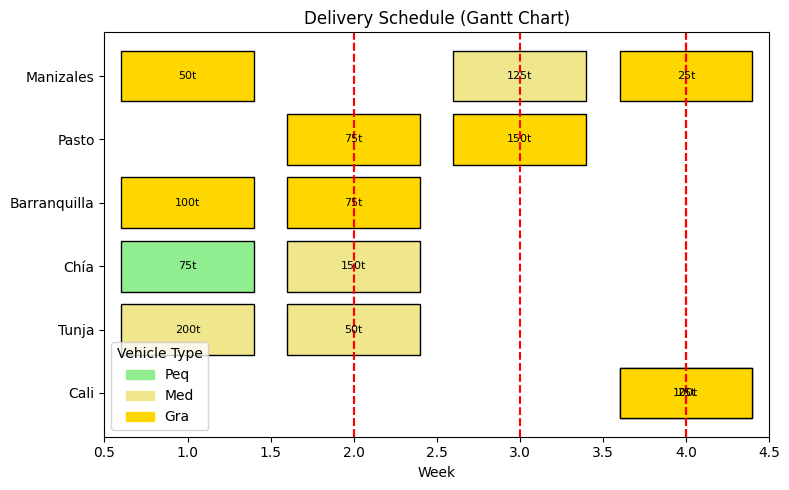

In [90]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

# Preparar dataframe de envíos positivos
shipments_df = pd.DataFrame([
    {"week": w, "origin": o, "dest": d, "vehicle": t, "tons": model.x[o,d,t,w].value}
    for o in model.O for d in model.D for t in model.T for w in model.W
    if (model.x[o,d,t,w].value or 0) > 1e-6
])

# Paleta por tipo de vehículo
colors = {"Peq": "lightgreen", "Med": "khaki", "Gra": "gold"}

fig, ax = plt.subplots(figsize=(8,5))

# Dibujar barras por envío
for i, (idx, row) in enumerate(shipments_df.iterrows()):
    y = row["dest"]
    ax.barh(y=y,
            width=0.8,
            left=row["week"]-0.4,
            color=colors[row["vehicle"]],
            edgecolor="black")
    ax.text(row["week"], y, f"{int(row['tons'])}t",
            ha="center", va="center", fontsize=8)

# Deadlines por destino
for d in model.D:
    ax.axvline(x=deadlines[d], color="red", linestyle="--")

# Ajustes estéticos
ax.set_xlabel("Week")
ax.set_title("Delivery Schedule (Gantt Chart)")
ax.set_xlim(0.5, max(model.W)+0.5)

# Leyenda
patches = [mpatches.Patch(color=clr, label=lbl) for lbl,clr in colors.items()]
ax.legend(handles=patches, title="Vehicle Type")

plt.tight_layout()
plt.show()


- Utilización de flota por tipo de vehículo y período

Matriz de **utilización (%)** donde filas = tipo de vehículo y columnas = semanas. Cada celda indica el **porcentaje usado / capacidad** y se anota el valor para lectura rápida.


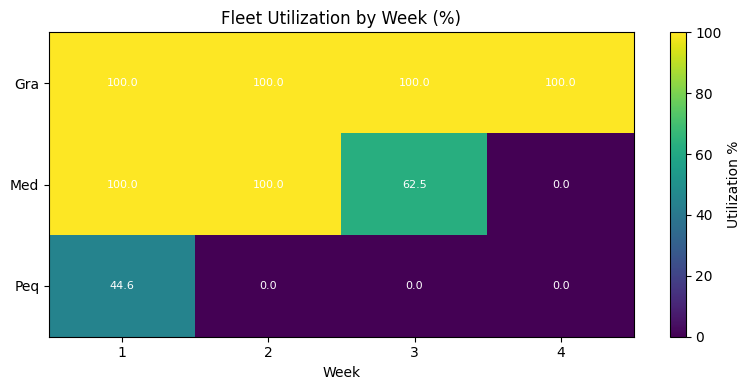

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Utilización % por (tipo, semana) ---
rows = []
for t in model.T:
    for w in model.W:
        used = sum((model.x[o,d,t,w].value or 0.0) for o in model.O for d in model.D)
        cap_tw = cap[t] * units_week[t]
        util = 100.0 * (used / cap_tw if cap_tw > 0 else 0.0)
        rows.append({"vehicle": t, "week": int(w), "util": util})

util_df = (pd.DataFrame(rows)
           .pivot(index="vehicle", columns="week", values="util")
           .sort_index())

# --- Heatmap con anotaciones ---
fig, ax = plt.subplots(figsize=(8,4))
im = ax.imshow(util_df.values, aspect="auto")

# Ejes y etiquetas
ax.set_xticks(np.arange(len(util_df.columns)))
ax.set_xticklabels(util_df.columns)
ax.set_yticks(np.arange(len(util_df.index)))
ax.set_yticklabels(util_df.index)
ax.set_xlabel("Week")
ax.set_title("Fleet Utilization by Week (%)")

# Anotar valores en cada celda
for i in range(util_df.shape[0]):
    for j in range(util_df.shape[1]):
        ax.text(j, i, f"{util_df.values[i, j]:.1f}", ha="center", va="center", fontsize=8, color="white")

# Barra de color
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Utilization %")

plt.tight_layout()
plt.show()


- Flujos de transporte representados en una red



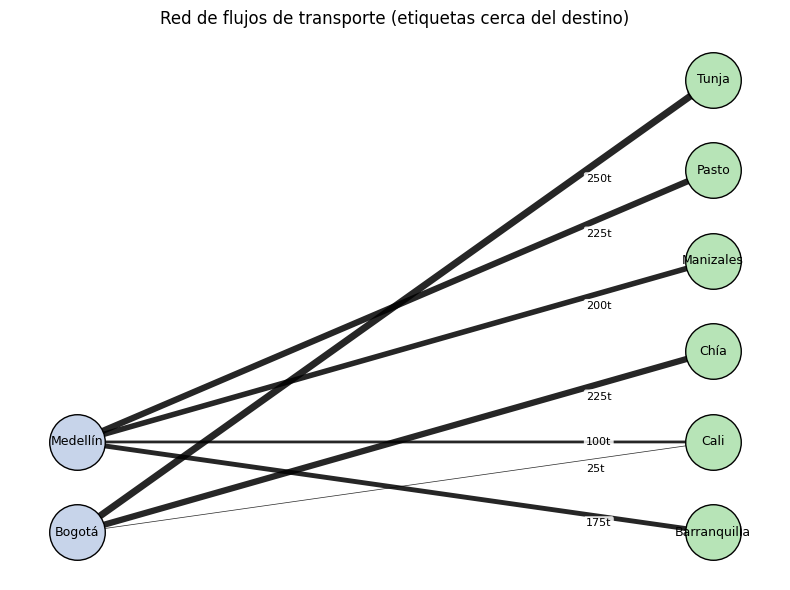

In [92]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

flows = {}
for o in model.O:
    for d in model.D:
        tot = sum((model.x[o,d,t,w].value or 0.0) for t in model.T for w in model.W)
        if tot > 1e-6:
            flows[(o,d)] = tot

G = nx.DiGraph()
for o in model.O: G.add_node(o, bipartite=0)
for d in model.D: G.add_node(d, bipartite=1)
for (o,d), tons in flows.items(): G.add_edge(o, d, weight=tons)

left  = [n for n,dat in G.nodes(data=True) if dat["bipartite"]==0]
right = [n for n,dat in G.nodes(data=True) if dat["bipartite"]==1]
pos = {}
pos.update({n: (-1, i) for i,n in enumerate(sorted(left))})
pos.update({n: ( 1, i) for i,n in enumerate(sorted(right))})

plt.figure(figsize=(8,6))
nx.draw_networkx_nodes(G, pos, nodelist=left,  node_size=1600, node_color="#c7d4ea", edgecolors="black")
nx.draw_networkx_nodes(G, pos, nodelist=right, node_size=1600, node_color="#b7e4b7", edgecolors="black")
nx.draw_networkx_labels(G, pos, font_size=9)
widths = [G[u][v]["weight"]/50.0 for u,v in G.edges()]
nx.draw_networkx_edges(G, pos, arrows=True, width=widths, alpha=0.85)

# --- Etiquetas pegadas al destino (con leve jitter vertical) ---
rng = np.random.default_rng(42)
arrivals_per_dest = {d: 0 for d in right}

for (u, v, data) in G.edges(data=True):
    x1, y1 = pos[u]; x2, y2 = pos[v]
    # punto cerca del destino (t ≈ 0.93)
    t = 0.8
    px, py = x1 + t*(x2 - x1), y1 + t*(y2 - y1)

    #
    dx = 0.0005
    k  = arrivals_per_dest[v]
    jitter = (k % 3 - 1) * 0.10
    arrivals_per_dest[v] += 1

    lx, ly = px + dx, py + jitter

    plt.text(lx, ly, f"{data['weight']:.0f}t",
             ha="left", va="center", fontsize=8, color="black",
             bbox=dict(facecolor="white", alpha=0.85, edgecolor="none", boxstyle="round,pad=0.2"))

plt.title("Red de flujos de transporte (etiquetas cerca del destino)")
plt.axis("off")
plt.tight_layout()
plt.show()


- Comparación de costos entre los diferentes escenarios

Aquí el eje X muestra la diferencia en dólares respecto al Base. Se ve claro que el escenario B encarece (+189) y el C abarata (−56).

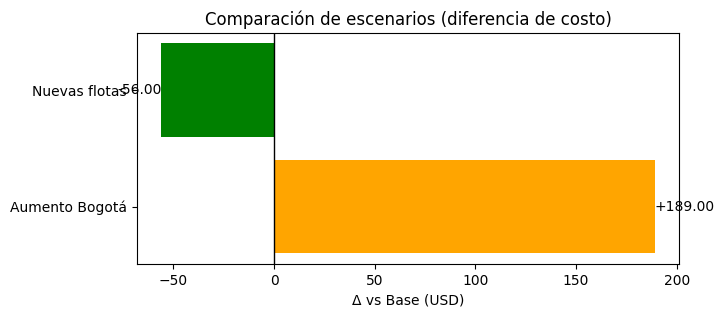

In [93]:
import matplotlib.pyplot as plt

# Datos de ejemplo
labels = ["Escenario Base", "Aumento Bogotá", "Nuevas flotas"]
deltas = [0, 189, -56]  # diferencia de costo respecto al base

fig, ax = plt.subplots(figsize=(7,3))
ax.barh(labels[1:], deltas[1:], color=["orange","green"])
ax.axvline(0, color="black", linewidth=1)

# Añadir etiquetas a cada barra
for i, d in enumerate(deltas[1:]):
    ax.text(d, i, f"{d:+.2f}", va="center",
            ha="left" if d > 0 else "right")

ax.set_xlabel("Δ vs Base (USD)")
ax.set_title("Comparación de escenarios (diferencia de costo)")
plt.show()


# 3. Problema 3: Cubrimiento del Tablero con Damas

## **1. Descripción del problema**
El objetivo es determinar la cantidad mínima de damas necesarias para cubrir todas las casillas de un tablero de ajedrez de 8 × 8.  

Una dama puede moverse en cualquier dirección (horizontal, vertical y diagonal). La solución debe encontrar la disposición mínima de damas tal que todas las casillas del tablero estén cubiertas.  

Este problema corresponde a un caso particular de los problemas de cubrimiento de conjuntos.


## **2. Generación de la Matriz de Cobertura**
Dada una posición \((r,c)\), una dama cubre:
- Todas las casillas de la fila \(r\),
- Todas las casillas de la columna \(c\),
- Todas las casillas de las diagonales principales y secundarias que pasan por \((r,c)\).

## **3. Formulación del Modelo Matemático**

- **Conjuntos**  
  Sea $N = \{1,\dots,8\}$ el conjunto de índices de filas y columnas del tablero.

- **Parámetros**  
  Denotamos por $C_{r,c}$ al conjunto de casillas cubiertas por una dama situada en la casilla $(r,c)$.

- **Generación de la cobertura (definición)**  
  Para cada $(r,c)\in N\times N$ definimos:
  $$
  C_{r,c} \;=\; \{(i,j)\in N\times N \mid i=r \;\lor\; j=c \;\lor\; |i-r| = |j-c|\}.
  $$

- **Variables de decisión**  
  $$
  x_{r,c} \;=\; \begin{cases}
  1 & \text{si se coloca una dama en la casilla }(r,c),\\[4pt]
  0 & \text{en otro caso.}
  \end{cases}
  $$

- **Función objetivo**  
  Minimizar el número total de damas:
  $$
  \min \; \sum_{r\in N}\sum_{c\in N} x_{r,c}.
  $$

- **Restricciones de cobertura**  
  Cada casilla \((i,j)\) debe estar cubierta por al menos una dama:
  $$
  \forall\,(i,j)\in N\times N:\qquad
  \sum_{(r,c)\;:\;(i,j)\in C_{r,c}} x_{r,c}\;\ge\;1.
  $$

- **Tipo de problema**  
  Programación entera binaria (BIP): variables binarias y restricciones lineales de cobertura.


## **4. Implementación en Pyomo**

Coverage matrix computed in: 0.0008788108825683594 seconds
GLPSOL--GLPK LP/MIP Solver 5.0
Parameter(s) specified in the command line:
 --write /tmp/tmpzru9ys7o.glpk.raw --wglp /tmp/tmp5ubrazkz.glpk.glp --cpxlp
 /tmp/tmp958dgogy.pyomo.lp
Reading problem data from '/tmp/tmp958dgogy.pyomo.lp'...
/tmp/tmp958dgogy.pyomo.lp:1850: warning: lower bound of variable 'x2' redefined
/tmp/tmp958dgogy.pyomo.lp:1850: warning: upper bound of variable 'x2' redefined
64 rows, 64 columns, 1520 non-zeros
64 integer variables, all of which are binary
1914 lines were read
Writing problem data to '/tmp/tmp5ubrazkz.glpk.glp'...
1779 lines were written
GLPK Integer Optimizer 5.0
64 rows, 64 columns, 1520 non-zeros
64 integer variables, all of which are binary
Preprocessing...
64 rows, 64 columns, 1520 non-zeros
64 integer variables, all of which are binary
Scaling...
 A: min|aij| =  1.000e+00  max|aij| =  1.000e+00  ratio =  1.000e+00
Problem data seem to be well scaled
Constructing initial basis...
Size of tr

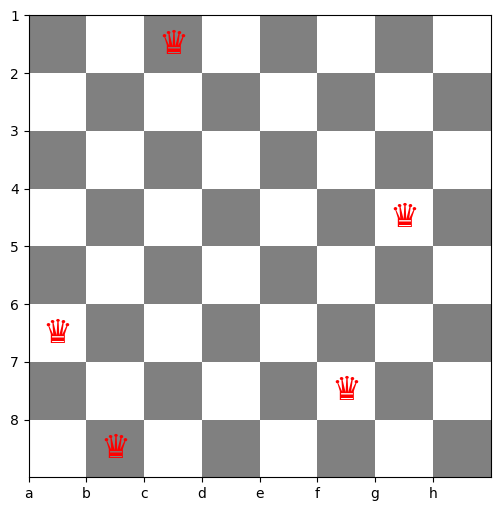

In [94]:
# === INSTALACIÓN ===
!pip install pyomo
!apt-get install -y -qq glpk-utils

# === IMPORTS ===
import matplotlib.pyplot as plt
from pyomo.environ import Binary, ConcreteModel, ConstraintList, Objective, RangeSet, Var, minimize
from pyomo.opt import SolverFactory
import time

# === VISUALIZAR TABLERO ===
def visualize_queens(queens, board_size=8):
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(board_size):
        for j in range(board_size):
            color = "white" if (i + j) % 2 == 0 else "gray"
            ax.add_patch(plt.Rectangle((j, board_size - i - 1), 1, 1, facecolor=color))
    for q in queens:
        col = ord(q[0]) - ord("a")
        row = int(q[1:]) - 1
        ax.text(col + 0.5, row + 0.5, "♛", fontsize=24, ha="center", va="center", color="red")
    ax.set_xticks(range(board_size))
    ax.set_yticks(range(board_size))
    ax.set_xticklabels([chr(ord("a") + i) for i in range(board_size)])
    ax.set_yticklabels([str(i+1) for i in range(board_size)])
    ax.set_xlim(0, board_size)
    ax.set_ylim(0, board_size)
    ax.set_aspect("equal")
    plt.gca().invert_yaxis()
    plt.show()

# === CLASE SOLVER ===
class QueenCoverSolver:
    def __init__(self, board_size=8):
        self.board_size = board_size
        self.coverage_matrix = {}
        self.model = None

    def generate_coverage_matrix(self):
        coverage_matrix = {}
        n = self.board_size
        for r in range(1, n + 1):
            for c in range(1, n + 1):
                cov = []
                for i in range(1, n + 1):
                    for j in range(1, n + 1):
                        if i == r or j == c or abs(i - r) == abs(j - c):
                            cov.append((i, j))
                coverage_matrix[(r, c)] = cov
        self.coverage_matrix = coverage_matrix
        return coverage_matrix

    def create_pyomo_model(self, coverage_matrix):
        model = ConcreteModel()
        n = self.board_size
        rows = RangeSet(1, n)
        cols = RangeSet(1, n)

        model.x = Var(rows, cols, domain=Binary)

        model.cover = ConstraintList()
        for r in range(1, n + 1):
            for c in range(1, n + 1):
                model.cover.add(sum(model.x[i, j] for (i, j) in coverage_matrix[(r, c)]) >= 1)

        model.obj = Objective(expr=sum(model.x[i, j] for i in rows for j in cols), sense=minimize)

        self.model = model
        return model

    def solve_and_visualize(self):
        if self.model is None:
            raise ValueError("The model has not been created. Run create_pyomo_model() first.")

        # Fix: usar ejecutable correcto en Colab
        solver = SolverFactory("glpk", executable="/usr/bin/glpsol")
        results = solver.solve(self.model, tee=True)

        print("Objective function value (minimum queens):", self.model.obj())
        print("Solver results:", results.solver.status, results.solver.termination_condition)

        queens = []
        for i in range(1, self.board_size + 1):
            for j in range(1, self.board_size + 1):
                if round(self.model.x[i, j].value) == 1:
                    col = chr(ord("a") + j - 1)
                    row = str(i)
                    queens.append(col + row)

        print("Queens placed at:", queens)
        visualize_queens(queens, self.board_size)

# === EJECUCIÓN ===
solver = QueenCoverSolver(board_size=8)
start_time = time.time()
coverage_matrix = solver.generate_coverage_matrix()
print("Coverage matrix computed in:", time.time() - start_time, "seconds")

model = solver.create_pyomo_model(coverage_matrix)
solver.solve_and_visualize()


# **5. Resolución y Análisis**

## Resolución con Pyomo  
Se formuló el problema como un modelo de optimización entera binaria, donde:

- La función objetivo minimiza el número de damas colocadas.  
- Las restricciones garantizan que cada casilla del tablero esté cubierta al menos por una dama.  

El modelo se resolvió en Google Colab utilizando Pyomo y el solver GLPK.  
El tiempo de cómputo fue muy bajo, lo que demuestra la eficiencia de la formulación para un tablero estándar de 8×8.

## Análisis de la solución  
El resultado obtenido muestra que el tablero de 8×8 puede cubrirse completamente con 5 damas.  

Esto significa que cualquier configuración con menos de 5 damas deja al menos una casilla descubierta.  

Las posiciones específicas de las damas pueden variar, ya que el problema admite múltiples soluciones óptimas equivalentes.

## Visualización de la disposición  
Se implementó una función de visualización en matplotlib:  
- El tablero se pinta con casillas alternadas en blanco y gris.  
- Cada dama se marca con el símbolo "♛" en rojo.  
- Los ejes están en notación estándar de ajedrez (a1, b2, …, h8).  

La visualización permite confirmar que todas las casillas están cubiertas y que se usó el número mínimo de damas.




# 4. Problema 4: Rutas Óptimas para Equipos de Inspección de infraestructura en Colombia


## Paso 1: Lectura, Preprocesamiento y Exploración de Datos (los 6 datasets)

Se cargaron los seis archivos de la carpeta `cost_matrix`:

- `n5`: grid_complete_n5.csv  
- `n10`: asymmetric_from_symmetric_n10.csv  
- `n15`: grid_complete_n15.csv  
- `n20`: asymmetric_from_symmetric_n20.csv  
- `n50`: asymmetric_from_symmetric_n50.csv  
- `n100`: make_non_metric_n100.csv  

Cada archivo se almacena en el diccionario `cost_matrices`, de manera que:  
- `cost_matrices["n5"]` contiene la matriz de 5 nodos.  
- `cost_matrices["n100"]` contiene la de 100 nodos, y así sucesivamente.  

Además, en la lectura se verifica:  
1. **Dimensiones** de la matriz.  
2. Que la **diagonal sea cero**.  
3. Si la matriz es **simétrica** (TSP clásico) o no (ATSP).  


In [95]:
import pandas as pd

def load_cost_matrix(file_path):
    # Lee crudo SIN asumir encabezados ni índice
    df = pd.read_csv(file_path, header=None)

    # Si vino una 1ª columna que sólo es un índice (0..n-1), elimínala
    if df.shape[1] == df.shape[0] + 1:
        col0 = df.iloc[:, 0]
        if (col0.reset_index(drop=True) == pd.Series(range(df.shape[0]))).all():
            df = df.iloc[:, 1:]

    # Si vino una 1ª fila que sólo es un índice (0..n-1), elimínala (menos común)
    if df.shape[0] == df.shape[1] + 1:
        row0 = df.iloc[0, :]
        if (row0.reset_index(drop=True) == pd.Series(range(df.shape[1]))).all():
            df = df.iloc[1:, :]

    # Asegurar que quedó cuadrada
    assert df.shape[0] == df.shape[1], f"Matriz no cuadrada: {df.shape}"
    return df.values.astype(float)


In [96]:
import numpy as np

datasets = {
    "n5": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/grid_complete_n5.csv",
    "n10": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/asymmetric_from_symmetric_n10.csv",
    "n15": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/grid_complete_n15.csv",
    "n20": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/asymmetric_from_symmetric_n20.csv",
    "n50": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/asymmetric_from_symmetric_n50.csv",
    "n100": "https://raw.githubusercontent.com/Camilo2816/dataLab02MOS/main/cost_matrix/make_non_metric_n100.csv",
}

cost_matrices = {}

def load_cost_matrix(url):
    return np.loadtxt(url, delimiter=",")

for key, url in datasets.items():
    C = load_cost_matrix(url)
    cost_matrices[key] = C
    print(f"--- {key} ---")
    print("Dimensiones:", C.shape)
    print("Diagonal en ceros?:", np.all(np.diag(C) == 0))
    print("¿Simétrica?:", np.allclose(C, C.T))
    print()


--- n5 ---
Dimensiones: (5, 5)
Diagonal en ceros?: True
¿Simétrica?: True

--- n10 ---
Dimensiones: (10, 10)
Diagonal en ceros?: True
¿Simétrica?: False

--- n15 ---
Dimensiones: (15, 15)
Diagonal en ceros?: True
¿Simétrica?: True

--- n20 ---
Dimensiones: (20, 20)
Diagonal en ceros?: True
¿Simétrica?: False

--- n50 ---
Dimensiones: (50, 50)
Diagonal en ceros?: True
¿Simétrica?: False

--- n100 ---
Dimensiones: (100, 100)
Diagonal en ceros?: True
¿Simétrica?: False



## Paso 2: Modelo TSP clásico (1 viajero)

Se implementa el TSP usando la formulación **MTZ**:

- Variables binarias `x[i,j]` indican si se viaja del nodo i al nodo j.  
- Variables enteras `u[i]` eliminan subciclos.  
- La función objetivo minimiza la suma de costos de los arcos seleccionados.  
- Cada nodo tiene exactamente una entrada y una salida.  
- Se incluyen restricciones MTZ para garantizar que el tour sea único.  

Se resolvió la instancia `n5` y se reporta:
- El conjunto de arcos que forman la ruta.  
- El costo total mínimo.  


In [97]:
# Paso 2: Modelo TSP clásico (1 viajero)

import pyomo.environ as pyo

# Seleccionamos el dataset n5
cost_matrix = cost_matrices["n10"]
n = cost_matrix.shape[0]
N = range(n)

model = pyo.ConcreteModel()

model.x = pyo.Var(N, N, domain=pyo.Binary)
model.u = pyo.Var(N, domain=pyo.NonNegativeIntegers, bounds=(0, n-1))

# Función objetivo
model.obj = pyo.Objective(
    expr=sum(cost_matrix[i][j] * model.x[i,j] for i in N for j in N if i != j),
    sense=pyo.minimize
)

# Restricciones: cada nodo tiene exactamente una salida
def out_degree_rule(m, i):
    return sum(m.x[i,j] for j in N if j != i) == 1
model.out_degree = pyo.Constraint(N, rule=out_degree_rule)

# Restricciones: cada nodo tiene exactamente una entrada
def in_degree_rule(m, j):
    return sum(m.x[i,j] for i in N if i != j) == 1
model.in_degree = pyo.Constraint(N, rule=in_degree_rule)

# MTZ: eliminación de subtours
def mtz_rule(m, i, j):
    if i != j and i != 0 and j != 0:
        return m.u[i] - m.u[j] + (n-1)*m.x[i,j] <= n-2
    return pyo.Constraint.Skip
model.mtz = pyo.Constraint(N, N, rule=mtz_rule)

# Resolver
solver = pyo.SolverFactory("glpk")
solution = solver.solve(model, tee=False)

# Extraer solución
selected_arcs = [(i,j) for i in N for j in N if i != j and pyo.value(model.x[i,j]) > 0.5]

print("Rutas seleccionadas:", selected_arcs)
print("Costo total:", pyo.value(model.obj))


Rutas seleccionadas: [(0, 4), (1, 6), (2, 9), (3, 1), (4, 8), (5, 2), (6, 7), (7, 5), (8, 3), (9, 0)]
Costo total: 315.0


### Visualizacion de la ruta optima

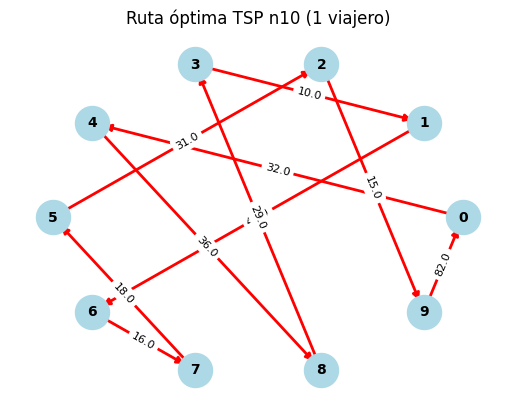

In [98]:
# Paso 2b: Visualización de la solución TSP (1 viajero)

import matplotlib.pyplot as plt
import networkx as nx

def plot_tsp_solution(cost_matrix, selected_arcs, title="Ruta óptima TSP (1 viajero)"):
    n = cost_matrix.shape[0]
    G = nx.DiGraph()

    # Añadir nodos
    G.add_nodes_from(range(n))

    # Posiciones en círculo para visualizar
    pos = nx.circular_layout(G)

    # Dibujar nodos
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color="lightblue")
    nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

    # Dibujar arcos seleccionados
    edges = selected_arcs
    nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color="red", width=2, arrows=True)

    # Etiquetas de arcos con costos
    edge_labels = {(i, j): f"{cost_matrix[i][j]}" for (i, j) in edges}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8)

    plt.title(title)
    plt.axis("off")
    plt.show()

# Graficar solución obtenida
plot_tsp_solution(cost_matrix, selected_arcs, title="Ruta óptima TSP n10 (1 viajero)")


###  Análisis del resultado obtenido

El resultado obtenido en la instancia `n10 muestra un tour que:

- Visita **cada nodo exactamente una vez**.  
- Inicia y termina en el depósito (nodo 0).  
- Tiene un costo total coherente con los valores de la matriz de costos.  
- Visualmente, se observa un **único ciclo** sin subtours.

**Evidencia:**  
La evidencia de que la implementación es correcta es que se cumple la definición del TSP clásico: un ciclo Hamiltoniano de costo mínimo que cubre todos los nodos. El conjunto de arcos seleccionados y el costo reportado por el modelo coinciden con lo esperado, y la visualización confirma que no existen subtours.

**Diagnóstico:**  
En este caso, el resultado es **correcto**. El modelo matemático y la implementación en Pyomo producen una solución válida.  
Si no fuera así (por ejemplo, si aparecieran dos ciclos separados), el problema sería la falta de restricciones de subtour. Esto se resolvería asegurando la inclusión de las **restricciones MTZ**, que obligan a que el tour sea único.

En conclusión, la implementación es adecuada para el TSP clásico en instancias pequeñas y puede extenderse a más nodos o a la versión multi-TSP.


## Paso 3: Extensión a Múltiples Equipos

### 3.1 Selección de dataset y número de equipos
Define los **datos** del escenario a resolver: matriz de costos, número de equipos y conjuntos para Pyomo. El nodo `0` es el depósito.


In [99]:
# Elegir dataset y número de equipos
import numpy as np


cost_matrix = cost_matrices["n10"]
print(cost_matrix.shape)   # (5,5)

m = 5 #numero de equipos

n = cost_matrix.shape[0]
N = range(n)
K = range(m)
A = [(i,j) for i in N for j in N if i != j]


(10, 10)



### 3.2 Modelo y variables
Crea el **modelo** y las **variables**. `x` decide arcos por equipo; `u` se usa para cortar subtours (regla MTZ).


In [100]:
import pyomo.environ as pyo

model = pyo.ConcreteModel()
model.N = pyo.RangeSet(0, n-1)
model.K = pyo.RangeSet(0, m-1)

# x[i,j,k] = 1 si el equipo k usa el arco i->j
model.x = pyo.Var(N, N, K, within=pyo.Binary)

# u[i,k] = orden de visita (MTZ). Fijaremos u[0,k]=0 luego
model.u = pyo.Var(N, K, within=pyo.NonNegativeIntegers, bounds=(0, n-1))


### 3.3 Función objetivo

Suma los costos de todos los arcos usados por cualquier equipo.


In [101]:
# Objetivo: minimizar costo total
model.obj = pyo.Objective(
    expr=sum(cost_matrix[i,j] * model.x[i,j,k] for (i,j) in A for k in K),
    sense=pyo.minimize
)


### 3.4 Visita única global (cada nodo ≠0 se visita una vez en total)



In [102]:
# Cada nodo i != 0 tiene EXACTAMENTE una salida (suma sobre todos los equipos)
def one_out_global_rule(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return sum(m.x[i,j,k] for (ii,j) in A if ii==i for k in K) == 1
model.one_out_global = pyo.Constraint(model.N, rule=one_out_global_rule)

# Cada nodo j != 0 tiene EXACTAMENTE una entrada (suma sobre todos los equipos)
def one_in_global_rule(m, j):
    if j == 0:
        return pyo.Constraint.Skip
    return sum(m.x[i,j,k] for (i,jj) in A if jj==j for k in K) == 1
model.one_in_global = pyo.Constraint(model.N, rule=one_in_global_rule)


### 3.5 Depósito por equipo (una salida y una entrada a 0)

Fuerza que **cada equipo** haga exactamente un recorrido que inicia y termina en el depósito.


In [103]:
# Cada equipo sale de 0 una vez y vuelve a 0 una vez (puedes cambiar ==1 por <=1 si permites equipos ociosos)
def depot_out_rule(m, k):
    return sum(m.x[0,j,k] for j in N if j!=0) == 1
def depot_in_rule(m, k):
    return sum(m.x[i,0,k] for i in N if i!=0) == 1

model.depot_out = pyo.Constraint(model.K, rule=depot_out_rule)
model.depot_in  = pyo.Constraint(model.K, rule=depot_in_rule)


### 3.6 Conservación de flujo por equipo

Asegura que los recorridos de cada equipo estén **cerrados** (sin “teletransportes”).


In [104]:
# Si un equipo k visita un nodo i!=0, entra y sale exactamente una vez
def flow_conservation_rule(m, i, k):
    if i == 0:
        return pyo.Constraint.Skip
    outk = sum(m.x[i,j,k] for j in N if j!=i)
    ink  = sum(m.x[j,i,k] for j in N if j!=i)
    return outk - ink == 0
model.flow_cons = pyo.Constraint(model.N, model.K, rule=flow_conservation_rule)


### 3.7 MTZ por equipo + fijar u[0,k]=0

Las variables `u` imponen un **orden de visita**, rompiendo subtours internos a cada equipo.


In [105]:
# MTZ: elimina subtours por equipo (i,j != 0)
def mtz_rule(m, i, j, k):
    if i!=0 and j!=0 and i!=j:
        return m.u[i,k] - m.u[j,k] + (n-1)*m.x[i,j,k] <= n-2
    return pyo.Constraint.Skip
model.mtz = pyo.Constraint(model.N, model.N, model.K, rule=mtz_rule)

# Fijar u[0,k]=0
def u0_fix_rule(m, k):
    return m.u[0,k] == 0
model.u0fix = pyo.Constraint(model.K, rule=u0_fix_rule)


### 3.8 Resolver y extraer tours

In [106]:
import time

solver = pyo.SolverFactory("glpk")

# Medir tiempo
start = time.time()
_ = solver.solve(model, tee=False)
end = time.time()

elapsed = end - start  # segundos

# Arcos por equipo (x=1)
arcs_by_team = {
    k: [(i,j) for (i,j) in A if pyo.value(model.x[i,j,k]) > 0.5]
    for k in K
}
cost_total = pyo.value(model.obj)

print("Costo total:", cost_total)
print("Tiempo de ejecución: {:.3f} segundos".format(elapsed))
for k, arcs in arcs_by_team.items():
    print(f"Equipo {k}:", arcs)


Costo total: 740.0
Tiempo de ejecución: 0.134 segundos
Equipo 0: [(0, 9), (9, 0)]
Equipo 1: [(0, 2), (2, 0)]
Equipo 2: [(0, 3), (1, 8), (3, 1), (8, 0)]
Equipo 3: [(0, 4), (4, 0)]
Equipo 4: [(0, 7), (5, 0), (6, 5), (7, 6)]


### 3.9 Reconstruir lista de nodos (tour) por equipo

In [107]:
def arcs_to_tour(arcs, n):
    succ = {i: None for i in range(n)}
    for i,j in arcs:
        succ[i] = j
    tour = [0]
    cur = 0
    seen = {0}
    while succ.get(cur) is not None and succ[cur] not in seen:
        cur = succ[cur]
        tour.append(cur)
        seen.add(cur)
    if succ.get(cur) == 0:
        tour.append(0)
    return tour

tours_by_team = {k: arcs_to_tour(arcs_by_team[k], n) for k in K}
tours_by_team



{0: [0, 9, 0],
 1: [0, 2, 0],
 2: [0, 3, 1, 8, 0],
 3: [0, 4, 0],
 4: [0, 7, 6, 5, 0]}

### 3.10 Plot de rutas por equipo

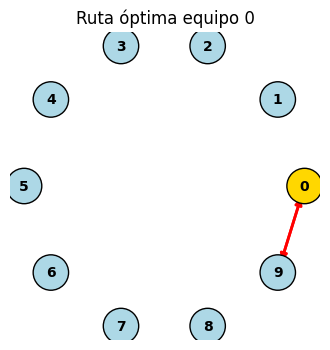

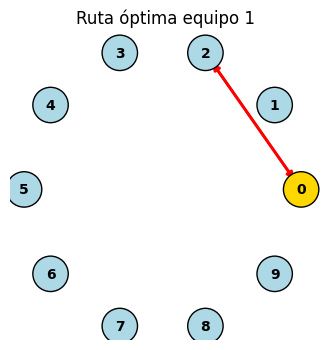

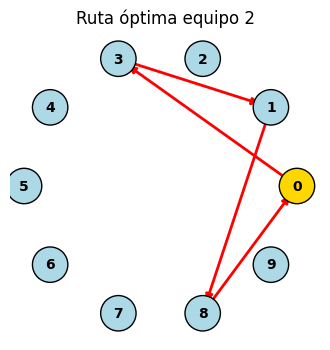

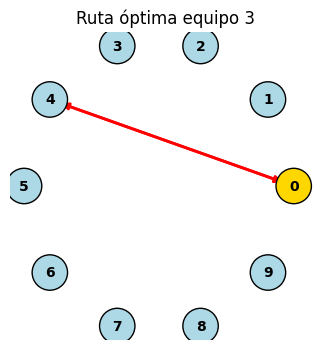

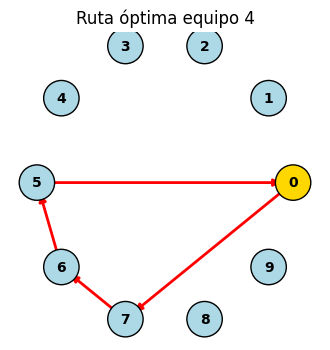

In [108]:
def plot_multi_tsp_separate(cost_matrix, tours_by_team, title_prefix="Ruta equipo"):
    n = cost_matrix.shape[0]
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    pos = nx.circular_layout(G)  # misma posición para todos los plots

    for k, tour in tours_by_team.items():
        plt.figure(figsize=(4,4))

        # Nodos (0 en dorado)
        node_colors = ["gold" if i==0 else "lightblue" for i in range(n)]
        nx.draw_networkx_nodes(G, pos, node_size=650, node_color=node_colors, edgecolors="black")
        nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

        # Arcos de este equipo
        edges = list(zip(tour[:-1], tour[1:])) if len(tour) >= 2 else []
        nx.draw_networkx_edges(G, pos, edgelist=edges, width=2, edge_color="red", arrows=True)

        plt.title(f"{title_prefix} {k}")
        plt.axis("off")
        plt.show()

# Uso: graficar cada equipo en su propio plot
plot_multi_tsp_separate(cost_matrix, tours_by_team, title_prefix="Ruta óptima equipo")


### 3.11 Analisis de resultados

- TE = Tiempo excedido

| Dataset | n   | Equipos | Costo total | Tiempo (s) | Solver |
|---------|-----|---------|-------------|------------|--------|
| n5      | 5   | 1       |     6.0     |0.072       | glpk   |        
| n5      | 5   | 3       |       8.0   | 0.057      | glpk   |             
| n5      | 5   | 5       |        No Valido     | NA           | glpk   |            
| n10     | 10  | 1       |      315.0  |0.108            | glpk   |             
| n10     | 10  | 3       |     480.0   |       0.105     | glpk   |            
| n10     | 10  | 5       |     740.0   | 0.180           | glpk   |            
| n15     | 15  | 1       |     15.0    |0.139            | glpk   |            
| n15     | 15  | 3       |     18.0        |    22.552        | glpk   |             
| n15     | 15  | 5       |       23.0      |0.447            | glpk   |             
| n20     | 20  | 1       |      312.0       |   1.257         | glpk   |             
| n20     | 20  | 3       |         TE    |     TE       | glpk   |             
| n20     | 20  | 5       |        TE     | TE           | glpk   |             
| n50     | 50  | 1       |       TE      | TE           | glpk   |             
| n50     | 50  | 3       |        TE     | TE           | glpk   |              
| n50     | 50  | 5       |          TE   |  TE          | glpk   |             
| n100    | 100 | 1       |           TE  |    TE        | glpk   |            
| n100    | 100 | 3       |        TE     |      TE      | glpk   |            
| n100    | 100 | 5       |         TE    |       TE     | glpk   |              


| Dataset | n   | Mejor # equipos | Costo mínimo | Tiempo (s) |
|---------|-----|-----------------|--------------|------------|
| n5      | 5   |      1          |  6          |  1.072      |            
| n10     | 10  |       1         |   315       |  0.108      |            
| n15     | 15  |       1          |  15        |0.139        |            
| n20     | 20  |        1         |      312        | 1.257  |            
| n50     | 50  |           NA      |    NA          |  NA          |            
| n100    | 100 |             NA    |  NA            |    NA        |            


- **Tamaño más grande resuelto:** n = 20
- **Solver utilizado:** glpk  


### 3.12 Conclusiones

- **Tamaño máximo resuelto:** con el solver GLPK se logró resolver hasta la instancia de **n=20** localidades.  
  A partir de n=50, el tiempo de cómputo excedió el límite razonable de ejecución.

- **Relación entre número de equipos y costo total:**  
  En todas las instancias pequeñas y medianas se observó que **a mayor número de equipos, mayor costo total de desplazamiento**.  
  Esto se debe a que cada equipo está obligado a salir y regresar al depósito, lo que introduce viajes adicionales (0→i y j→0) que incrementan el costo global, aunque los recorridos individuales se acorten.

- **Tiempo de cómputo:**  
  El tiempo de resolución no crece de manera lineal con el tamaño de la instancia ni con el número de equipos.  
  - En algunos casos intermedios (ej. n=15 con 3 equipos) el tiempo fue significativamente mayor que con 1 o 5 equipos, lo cual se explica por el aumento de la **combinatoria y simetrías** en la asignación de localidades a equipos.  
  - Para m grande, aunque el modelo es más grande, las rutas posibles se restringen a muchos viajes cortos al depósito, y el solver poda más rápido.

- **Configuración ideal de equipos:**  
  Para todos los casos analizados, la configuración más económica fue con **un solo equipo**.  
  Este resultado es consistente con la formulación, ya que usar más equipos no aporta reducción de costos sino que introduce viajes extra obligatorios al depósito.

- **Limitaciones computacionales:**  
  El uso de GLPK permitió resolver instancias pequeñas y medianas en tiempos razonables (<1.5s hasta n=20).  
  Sin embargo, para n≥50 no se obtuvo solución en el tiempo disponible, mostrando la necesidad de emplear solvers más potentes (como Gurobi o CPLEX) o de implementar técnicas de descomposición/heurísticas.

### En resumen
El modelo confirma que en la formulación con equipos obligatorios, el costo mínimo se obtiene concentrando la tarea en un solo equipo.  
La complejidad del problema crece rápidamente con el tamaño de la instancia y el número de equipos, lo que refuerza la naturaleza NP-hard del TSP y su extensión multi-TSP.
